In [1]:
import numpy as np
import pandas as pd
import scipy.sparse.linalg as linalg
import scipy.linalg as slin
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import sys
sys.path.insert(0, '../data')
from load import load_stats, load_history

pd.options.mode.chained_assignment = None

## Load Data

In [2]:
players = load_stats()
history = load_history()

In [3]:
# valid tournament defined as any tournament with a change in rating less than 1500
def valid_tournament(tournament):
    if tournament['Final Rating'] - tournament['Initial Rating'] > 1500:
        return False
    return True

history['valid tournament'] = history.apply(valid_tournament, axis=1)
history = history[history['valid tournament'] == True]

## 100 bin width

In [9]:
# all tournament rating transitions
transitions = history[['Initial Rating', 'Final Rating']]

# setting up bins for cuts
bin_width = 100
bins = np.arange(0, 3000, bin_width)
labels = np.arange(0, bins.size-1)

# cutting all transitions into bins
transitions['initial bin'] = pd.cut(transitions['Initial Rating'], bins, labels=labels, include_lowest=True)
transitions['final bin'] = pd.cut(transitions['Final Rating'], bins, labels=labels, include_lowest=True)
transitions = transitions[['initial bin', 'final bin']]

# finding probability of each transition from bin to bin
probs = (transitions.value_counts() / transitions.value_counts().groupby(level=0, observed=True).sum())

# define stochastic matrix
p_size = bins.size-1
p = np.zeros((p_size, p_size))

for i, f in probs.index:
    p[i, f] = probs[i, f]

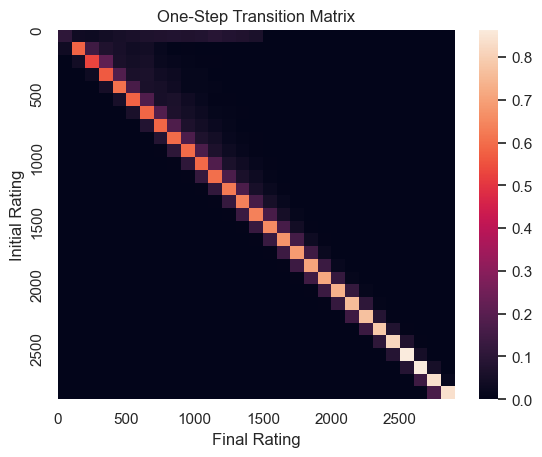

In [10]:
sns.heatmap(p)
plt.title("One-Step Transition Matrix")
plt.xlabel("Final Rating")
plt.ylabel("Initial Rating")
plt.xticks(np.arange(0, 30, 5), np.arange(0, 3000, 500))
plt.yticks(np.arange(0, 30, 5), np.arange(0, 3000, 500))
plt.show()

In [11]:
def plot_pi(pi, title=""):
    sns.scatterplot(x=bins[:-1], y=pi, marker='.')
    plt.xlabel('Rating')
    plt.ylabel('Probability')
    plt.title(title)
    plt.show()

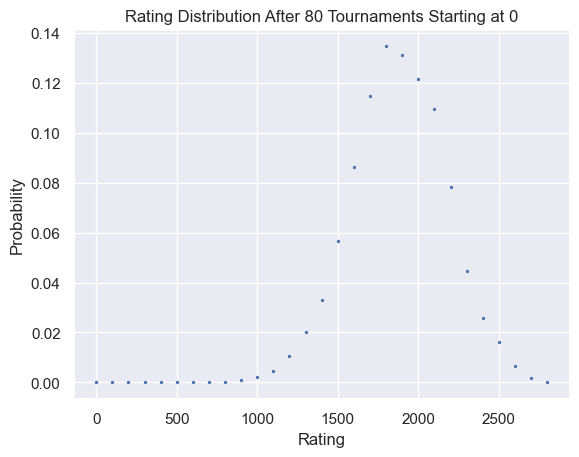

In [12]:
init_rating = 0
tournaments = 80

pi0 = np.zeros(p_size)
pi0[init_rating // bin_width] = 1
pi = pi0 @ np.linalg.matrix_power(p, tournaments)
plot_pi(pi, title=f"Rating Distribution After {tournaments} Tournaments Starting at {init_rating}")

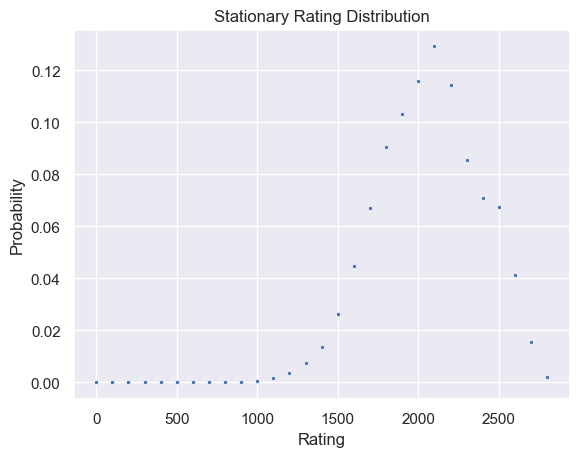

In [13]:
def stationary_distribution(P):
    n = P.shape[0]
    A = np.vstack([P.T - np.eye(n), np.ones(n)])
    b = np.append(np.zeros(n), 1)
    pi = np.linalg.lstsq(A, b, rcond=None)[0]
    return pi

plot_pi(stationary_distribution(p), title="Stationary Rating Distribution")

## Mean Recurrence Time

In [14]:
# all tournament rating transitions
transitions = history[['Initial Rating', 'Final Rating']]

# setting up bins for cuts
bin_width = 100
bins = np.arange(0, 3000, bin_width)
labels = np.arange(0, bins.size-1)

# cutting all transitions into bins
transitions['initial bin'] = pd.cut(transitions['Initial Rating'], bins, labels=labels, include_lowest=True)
transitions['final bin'] = pd.cut(transitions['Final Rating'], bins, labels=labels, include_lowest=True)
transitions = transitions[['initial bin', 'final bin']]

# finding probability of each transition from bin to bin
probs = (transitions.value_counts() / transitions.value_counts().groupby(level=0, observed=True).sum())

# define stochastic matrix
p_size = bins.size-1
p = np.zeros((p_size, p_size))

for i, f in probs.index:
    p[i, f] = probs[i, f]

In [15]:
# find the mean first passage time m_ij, or the expected time it takes to reach state j for the first time, given you start at state i
def mean_first_passage_time(p):
    n = len(p)
    recurrence = 1 / stationary_distribution(p)
    M = np.zeros((n, n))
    
    for j in range(n):
        p_tilda = np.delete(np.delete(p, j, axis=1), j, axis=0)
        m_tilda = np.linalg.solve(p_tilda - np.identity(n-1), -np.ones(n-1))
        m_j = np.insert(m_tilda, j, recurrence[j])
        M[:, j] = m_j

    return M

In [16]:
mfpt = mean_first_passage_time(p)

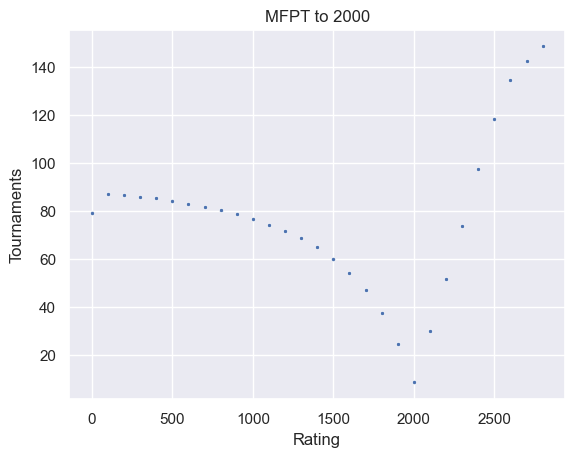

In [17]:
def plot_mean_first_passage_time(mfpt, rating):
    sns.scatterplot(x=bins[:-1], y=mfpt[:, rating//100], marker='.')
    plt.title(f"MFPT to {rating}")
    plt.xlabel('Rating')
    plt.ylabel("Tournaments")
    plt.show()

plot_mean_first_passage_time(mfpt, 2000)

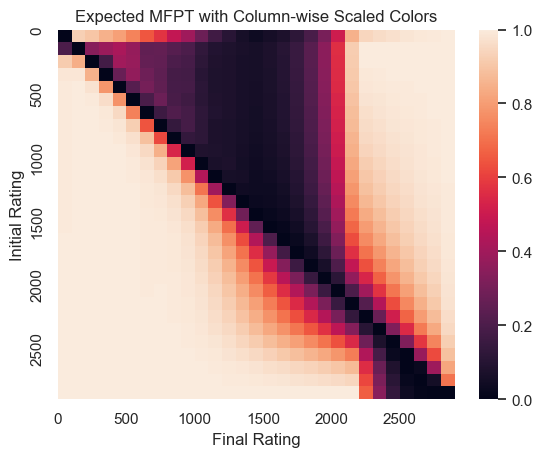

In [18]:
# apply min-max scaling
mfpt_df = pd.DataFrame(mfpt)
mfpt_scaled = mfpt_df.copy()
for col in mfpt_df.columns:
    min_val = mfpt_df[col].min()
    max_val = mfpt_df[col].max()
    if (max_val - min_val) != 0: # Avoid division by zero for constant columns
        mfpt_scaled[col] = (mfpt_df[col] - min_val) / (max_val - min_val)
    else:
        mfpt_scaled[col] = 0.5


sns.heatmap(mfpt_scaled)
plt.title("Expected MFPT with Column-wise Scaled Colors")
plt.xlabel("Final Rating")
plt.ylabel("Initial Rating")
plt.xticks(np.arange(0, 30, 5), np.arange(0, 3000, 500))
plt.yticks(np.arange(0, 30, 5), np.arange(0, 3000, 500))
plt.show()